<h1 style="color: green; font-size: 48px; text-align: center;">Autonomous ESG Intelligence Platform</h1>
<h3 style="color: #2e7d32; text-align: center;">Building a Free, GraphRAG-Based Alternative to MSCI ESG Ratings</h3>
<center>
    <img src="https://upload.wikimedia.org/wikipedia/commons/2/2c/Rotating_earth_%28large%29.gif" alt="rotating earth" height="260" width="260">
</center>

<h1 id="Introduction" tabindex="0">👋 Introduction</h1>
<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    The objective of this project is to build a transparent, open pipeline that estimates the
    <b>Environmental, Social and Governance (ESG)</b> risk of portfolio companies &mdash; a free
    alternative to expensive institutional ratings such as MSCI. The platform ingests company,
    supply-chain and controversy data, builds a <b>Knowledge Graph</b>, propagates hidden
    supply-chain risk, answers natural-language questions with <b>GraphRAG</b> (multi-hop
    retrieval), and auto-classifies every company under the EU's <b>SFDR Article 8 / 9 / 6</b>
    framework with clause-level justification.
</div>

<h1 id="Problem-Statement" tabindex="0">📚 Problem Statement</h1>
<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    Asset managers must comply with <b>EU SFDR</b> and <b>SEC ESG</b> disclosure rules, yet
    commercial ESG data costs <b>$50&ndash;200K / year</b> and manually analysing a single
    company's 10-K filings, sustainability reports and controversy databases takes <b>6&ndash;8
    hours</b>. Crucially, conventional analysis misses <b>hidden upstream exposure</b> &mdash;
    risk that sits three tiers down the supply chain. We automate this end-to-end at near-zero
    cost, surfacing both direct and inherited ESG risk on every portfolio company.
</div>

<h1 id="Feature-Description" tabindex="0">🔭 Data &amp; Feature Description</h1>
<div style="font-family:verdana; font-size: 20px; line-height: 1.7em;">
<ol>
<li><p><strong><code>environmental_score</code></strong>: 0&ndash;100 score for a company's environmental performance (emissions, water, climate alignment).</p></li>
<li><p><strong><code>social_score</code></strong>: 0&ndash;100 score for social factors (labour rights, community, health &amp; safety).</p></li>
<li><p><strong><code>governance_score</code></strong>: 0&ndash;100 score for governance quality (board oversight, disclosure, audit, anti-bribery).</p></li>
<li><p><strong><code>sustainable_investment_pct</code></strong>: Share of revenue/assets aligned with sustainable activities &mdash; a key SFDR threshold.</p></li>
<li><p><strong><code>fossil_fuel_exposure</code></strong>: Boolean flag for material fossil-fuel exposure; caps a company below Article 9.</p></li>
<li><p><strong><code>supply_chain</code></strong>: Buyer &rarr; supplier edges with a <code>tier</code> (1/2/3) describing sourcing depth.</p></li>
<li><p><strong><code>controversies</code></strong>: Dated ESG events with a <code>severity</code> (1&ndash;5) attached to companies or suppliers.</p></li>
<li><p><strong><code>esg_documents</code></strong>: SEC-EDGAR-style narrative filings used as grounding evidence for retrieval.</p></li>
</ol>
<p>
Together these capture a company's intrinsic ESG profile, its upstream dependencies, and the
real-world events that should move its rating &mdash; everything needed to reproduce an
institutional-grade assessment.
</p>
</div>

<h1 id="Project-Goals" tabindex="0">🎯 Project Goals</h1>
<div class="alert alert-block alert-warning" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    <ul>
        <li>Perform exploratory data analysis (EDA) on company ESG scores, sectors and controversies.</li>
        <li>Build a <b>Knowledge Graph</b> of companies &rarr; suppliers &rarr; ESG events with <code>networkx</code>.</li>
        <li>Propagate <b>supply-chain risk</b> across tiers so hidden upstream exposure surfaces on buyers.</li>
        <li>Implement <b>GraphRAG</b> &mdash; multi-hop retrieval that plain vector RAG cannot perform.</li>
        <li>Generate grounded, evidence-cited ESG narratives and auto-classify each company under <b>SFDR</b>.</li>
    </ul>
</div>

<h1 id="Importing-Libraries" tabindex="0">Importing Libraries</h1>

In [1]:
import json
import re
from collections import Counter

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set(font_scale=1.1)

<h1 id="Load-Data" tabindex="0">Load Data</h1>
<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 18px; line-height: 1.7em; border-radius: 1.3em;">
    The four raw collections (companies + suppliers, supply-chain edges, controversy events and
    ESG filings) are embedded inline so this notebook runs <b>fully self-contained on Kaggle</b>
    &mdash; no datasets, GPU, database or internet required.
</div>

In [2]:
companies = [{'id': 'C001',
  'name': 'Helios Renewable Energy',
  'ticker': 'HLRE',
  'sector': 'Renewable Energy',
  'region': 'European Union',
  'in_portfolio': True,
  'environmental_score': 88,
  'social_score': 79,
  'governance_score': 82,
  'sustainable_investment_pct': 0.91,
  'fossil_fuel_exposure': False},
 {'id': 'C002',
  'name': 'Northwind Logistics',
  'ticker': 'NWLG',
  'sector': 'Transportation',
  'region': 'European Union',
  'in_portfolio': True,
  'environmental_score': 61,
  'social_score': 70,
  'governance_score': 74,
  'sustainable_investment_pct': 0.42,
  'fossil_fuel_exposure': True},
 {'id': 'C003',
  'name': 'Meridian Semiconductors',
  'ticker': 'MRDS',
  'sector': 'Technology Hardware',
  'region': 'United States',
  'in_portfolio': True,
  'environmental_score': 66,
  'social_score': 58,
  'governance_score': 71,
  'sustainable_investment_pct': 0.35,
  'fossil_fuel_exposure': False},
 {'id': 'C004',
  'name': 'Verdant Foods Group',
  'ticker': 'VFDG',
  'sector': 'Consumer Staples',
  'region': 'European Union',
  'in_portfolio': True,
  'environmental_score': 72,
  'social_score': 81,
  'governance_score': 77,
  'sustainable_investment_pct': 0.58,
  'fossil_fuel_exposure': False},
 {'id': 'C005',
  'name': 'Atlas Heavy Industries',
  'ticker': 'ATHI',
  'sector': 'Industrials',
  'region': 'United States',
  'in_portfolio': True,
  'environmental_score': 44,
  'social_score': 55,
  'governance_score': 60,
  'sustainable_investment_pct': 0.18,
  'fossil_fuel_exposure': True},
 {'id': 'S101',
  'name': 'Kivu Minerals Ltd',
  'ticker': None,
  'sector': 'Mining',
  'region': 'Central Africa',
  'in_portfolio': False,
  'environmental_score': 31,
  'social_score': 28,
  'governance_score': 35,
  'sustainable_investment_pct': 0.05,
  'fossil_fuel_exposure': False},
 {'id': 'S102',
  'name': 'Pacific Circuit Assembly',
  'ticker': None,
  'sector': 'Electronics Manufacturing',
  'region': 'Southeast Asia',
  'in_portfolio': False,
  'environmental_score': 52,
  'social_score': 41,
  'governance_score': 49,
  'sustainable_investment_pct': 0.12,
  'fossil_fuel_exposure': False},
 {'id': 'S103',
  'name': 'Delta Freight Carriers',
  'ticker': None,
  'sector': 'Transportation',
  'region': 'European Union',
  'in_portfolio': False,
  'environmental_score': 48,
  'social_score': 63,
  'governance_score': 66,
  'sustainable_investment_pct': 0.22,
  'fossil_fuel_exposure': True},
 {'id': 'S104',
  'name': 'Greenfield Agro Supply',
  'ticker': None,
  'sector': 'Agriculture',
  'region': 'South America',
  'in_portfolio': False,
  'environmental_score': 57,
  'social_score': 69,
  'governance_score': 64,
  'sustainable_investment_pct': 0.33,
  'fossil_fuel_exposure': False},
 {'id': 'S105',
  'name': 'Summit Steelworks',
  'ticker': None,
  'sector': 'Materials',
  'region': 'United States',
  'in_portfolio': False,
  'environmental_score': 38,
  'social_score': 47,
  'governance_score': 52,
  'sustainable_investment_pct': 0.09,
  'fossil_fuel_exposure': True}]

In [3]:
supply_chain = [{'buyer': 'C003',
  'supplier': 'S101',
  'tier': 2,
  'relationship': 'raw_materials',
  'commodity': 'cobalt, tantalum'},
 {'buyer': 'C003', 'supplier': 'S102', 'tier': 1, 'relationship': 'assembly', 'commodity': 'circuit boards'},
 {'buyer': 'S102',
  'supplier': 'S101',
  'tier': 1,
  'relationship': 'raw_materials',
  'commodity': 'tantalum capacitors'},
 {'buyer': 'C002',
  'supplier': 'S103',
  'tier': 1,
  'relationship': 'freight',
  'commodity': 'diesel road haulage'},
 {'buyer': 'C004',
  'supplier': 'S104',
  'tier': 1,
  'relationship': 'ingredients',
  'commodity': 'soy, palm derivatives'},
 {'buyer': 'C005',
  'supplier': 'S105',
  'tier': 1,
  'relationship': 'raw_materials',
  'commodity': 'structural steel'},
 {'buyer': 'C005',
  'supplier': 'S101',
  'tier': 2,
  'relationship': 'raw_materials',
  'commodity': 'specialty alloys'},
 {'buyer': 'C001',
  'supplier': 'S105',
  'tier': 2,
  'relationship': 'raw_materials',
  'commodity': 'turbine steel'},
 {'buyer': 'C002',
  'supplier': 'S105',
  'tier': 2,
  'relationship': 'raw_materials',
  'commodity': 'fleet chassis steel'}]

In [4]:
controversies = [{'id': 'EV001',
  'company_id': 'S101',
  'date': '2026-02-11',
  'category': 'Social',
  'subcategory': 'Conflict Minerals',
  'severity': 5,
  'headline': 'Kivu Minerals linked to conflict-mineral sourcing in artisanal mines',
  'source': 'Controversy Monitor / NGO Report'},
 {'id': 'EV002',
  'company_id': 'S101',
  'date': '2026-03-04',
  'category': 'Environmental',
  'subcategory': 'Water Pollution',
  'severity': 4,
  'headline': 'Tailings discharge contaminates local watershed near Kivu operations',
  'source': 'Controversy Monitor / Local News'},
 {'id': 'EV003',
  'company_id': 'S102',
  'date': '2026-01-22',
  'category': 'Social',
  'subcategory': 'Labor Rights',
  'severity': 3,
  'headline': 'Pacific Circuit Assembly cited for excessive overtime at two plants',
  'source': 'Controversy Monitor / Labor Audit'},
 {'id': 'EV004',
  'company_id': 'C005',
  'date': '2026-02-28',
  'category': 'Environmental',
  'subcategory': 'Emissions',
  'severity': 4,
  'headline': 'Atlas Heavy Industries exceeds permitted NOx emissions at flagship plant',
  'source': 'Controversy Monitor / Regulator Filing'},
 {'id': 'EV005',
  'company_id': 'S105',
  'date': '2026-03-19',
  'category': 'Governance',
  'subcategory': 'Anti-Competition',
  'severity': 3,
  'headline': 'Summit Steelworks under antitrust review over regional price coordination',
  'source': 'Controversy Monitor / Press'},
 {'id': 'EV006',
  'company_id': 'S103',
  'date': '2026-04-02',
  'category': 'Environmental',
  'subcategory': 'Emissions',
  'severity': 2,
  'headline': 'Delta Freight Carriers fleet emissions above sector benchmark',
  'source': 'Controversy Monitor / Dataset'},
 {'id': 'EV007',
  'company_id': 'C002',
  'date': '2026-04-15',
  'category': 'Governance',
  'subcategory': 'Disclosure',
  'severity': 2,
  'headline': 'Northwind Logistics late on mandatory CSRD sustainability disclosure',
  'source': 'Controversy Monitor / Regulator Filing'}]

In [5]:
documents = [{'doc_id': 'D001',
  'company_id': 'C001',
  'source': 'SEC EDGAR 10-K / Sustainability Report',
  'text': 'Helios Renewable Energy generates 91 percent of revenue from solar and wind assets. The company '
          'reports net-zero scope 1 and 2 emissions and aligns capital expenditure with the EU Taxonomy '
          'climate mitigation objective. Board oversight of climate risk is formalised through a dedicated '
          'sustainability committee.'},
 {'doc_id': 'D002',
  'company_id': 'C002',
  'source': 'SEC EDGAR 10-K / CSRD Filing',
  'text': 'Northwind Logistics operates a diesel-heavy road freight fleet and retains material fossil fuel '
          'exposure. The company has committed to fleet electrification by 2030 but currently sources road '
          'haulage from Delta Freight Carriers, whose emissions exceed sector benchmarks. A mandatory CSRD '
          'disclosure was filed late this year.'},
 {'doc_id': 'D003',
  'company_id': 'C003',
  'source': 'SEC EDGAR 10-K / Supplier Disclosure',
  'text': 'Meridian Semiconductors assembles circuit boards through Pacific Circuit Assembly and sources '
          'tantalum and cobalt upstream from Kivu Minerals. The company acknowledges conflict-mineral '
          'due-diligence obligations under Dodd-Frank Section 1502 and is strengthening supplier audits '
          'across tier-1 and tier-2 vendors.'},
 {'doc_id': 'D004',
  'company_id': 'C004',
  'source': 'SEC EDGAR 10-K / Sustainability Report',
  'text': 'Verdant Foods Group sources soy and palm derivatives from Greenfield Agro Supply and maintains a '
          'deforestation-free sourcing policy. The company promotes 58 percent sustainable investment '
          'alignment and publishes Scope 3 agricultural emissions in line with GRI standards.'},
 {'doc_id': 'D005',
  'company_id': 'C005',
  'source': 'SEC EDGAR 10-K / Regulator Filing',
  'text': 'Atlas Heavy Industries retains high fossil fuel exposure and recently exceeded permitted NOx '
          'emissions at its flagship plant. It procures structural steel from Summit Steelworks, currently '
          'under antitrust review, and specialty alloys upstream from Kivu Minerals. Governance reforms are '
          'described as in progress.'}]

In [6]:
# Master company table + derived base ESG score (mean of the three pillars)
companies_df = pd.DataFrame(companies)
companies_df["base_esg"] = companies_df[
    ["environmental_score", "social_score", "governance_score"]
].mean(axis=1).round(1)

portfolio_df = companies_df[companies_df["in_portfolio"]].reset_index(drop=True)
companies_df.head(10)

,id,name,ticker,sector,region,in_portfolio,environmental_score,social_score,governance_score,sustainable_investment_pct,fossil_fuel_exposure,base_esg
0,C001,Helios Renewable Energy,HLRE,Renewable Energy,European Union,True,88,79,82,0.91,False,83.0
1,C002,Northwind Logistics,NWLG,Transportation,European Union,True,61,70,74,0.42,True,68.3
2,C003,Meridian Semiconductors,MRDS,Technology Hardware,United States,True,66,58,71,0.35,False,65.0
3,C004,Verdant Foods Group,VFDG,Consumer Staples,European Union,True,72,81,77,0.58,False,76.7
4,C005,Atlas Heavy Industries,ATHI,Industrials,United States,True,44,55,60,0.18,True,53.0
5,S101,Kivu Minerals Ltd,NaN,Mining,Central Africa,False,31,28,35,0.05,False,31.3
6,S102,Pacific Circuit Assembly,NaN,Electronics Manufacturing,Southeast Asia,False,52,41,49,0.12,False,47.3
7,S103,Delta Freight Carriers,NaN,Transportation,European Union,False,48,63,66,0.22,True,59.0
8,S104,Greenfield Agro Supply,NaN,Agriculture,South America,False,57,69,64,0.33,False,63.3
9,S105,Summit Steelworks,NaN,Materials,United States,False,38,47,52,0.09,True,45.7


<h1 id="EDA" tabindex="0">🔍 Exploratory Data Analysis (EDA)</h1>
<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    The goal of Exploratory Data Analysis (EDA) is to understand the structure of the ESG
    universe before any modelling. By visualising the score distributions, sector mix and
    controversy landscape, we learn which companies and conditions are most associated with
    elevated ESG risk.
</div>

<h2 id="Key-Objectives-of-EDA" tabindex="0">📊 Key Objectives of EDA</h2>
<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    <ul>
        <li>Examine the distribution of the three ESG pillar scores and the composite base score.</li>
        <li>Understand how <code>sustainable_investment_pct</code> and <code>fossil_fuel_exposure</code> vary across companies.</li>
        <li>Profile controversy events by ESG category and severity.</li>
        <li>Compare ESG performance across <code>sector</code>.</li>
        <li>Identify correlations between the ESG pillars using a correlation heatmap.</li>
    </ul>
</div>

<h2 id="Null-Value-Check" tabindex="0">Null Value Check</h2>

In [7]:
null_report = pd.DataFrame({
    "Columns": companies_df.columns,
    "# Null": companies_df.isnull().sum().values,
})
null_report

,Columns,# Null
0,id,0
1,name,0
2,ticker,5
3,sector,0
4,region,0
5,in_portfolio,0
6,environmental_score,0
7,social_score,0
8,governance_score,0
9,sustainable_investment_pct,0


<h2 id="Summary-Statistics" tabindex="0">Summary Statistics</h2>

In [8]:
numeric_cols = ["environmental_score", "social_score", "governance_score",
                "sustainable_investment_pct", "base_esg"]
companies_df[numeric_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
environmental_score,10.0,55.70,16.92,31.00,45.00,54.50,64.75,88.00
social_score,10.0,59.10,16.89,28.00,49.00,60.50,69.75,81.00
governance_score,10.0,63.00,14.38,35.00,54.00,65.00,73.25,82.00
sustainable_investment_pct,10.0,0.32,0.26,0.05,0.14,0.28,0.40,0.91
base_esg,10.0,59.26,15.44,31.30,48.72,61.15,67.47,83.00


<h2 id="Univariate-Analysis" tabindex="0">Univariate Analysis</h2>

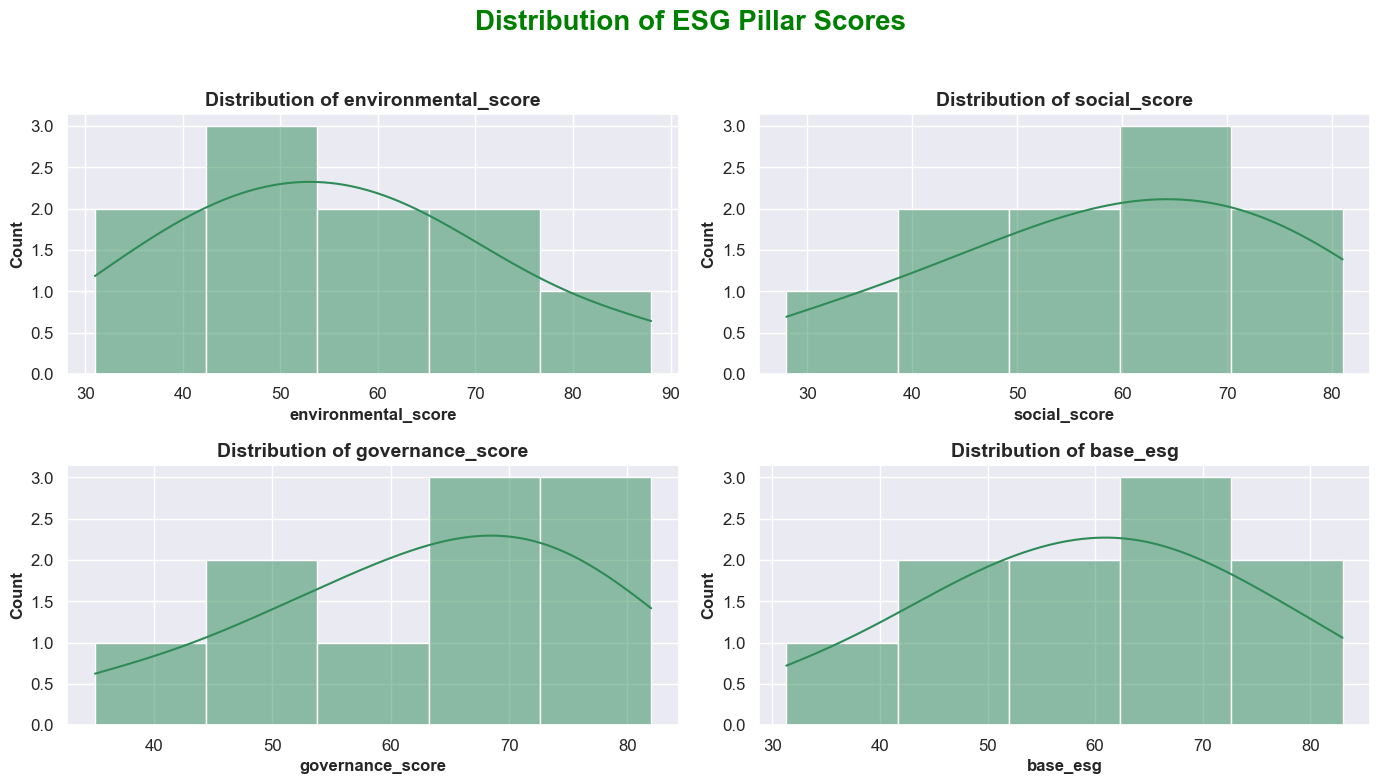

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, feature in enumerate(["environmental_score", "social_score",
                             "governance_score", "base_esg"]):
    sns.histplot(data=companies_df, x=feature, ax=axes[i], kde=True, color="seagreen")
    axes[i].set_title(f"Distribution of {feature}", fontweight="bold", fontsize=14)
    axes[i].set_xlabel(feature, fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Count", fontsize=12, fontweight="bold")

plt.suptitle("Distribution of ESG Pillar Scores", fontsize=20, fontweight="bold", color="green")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

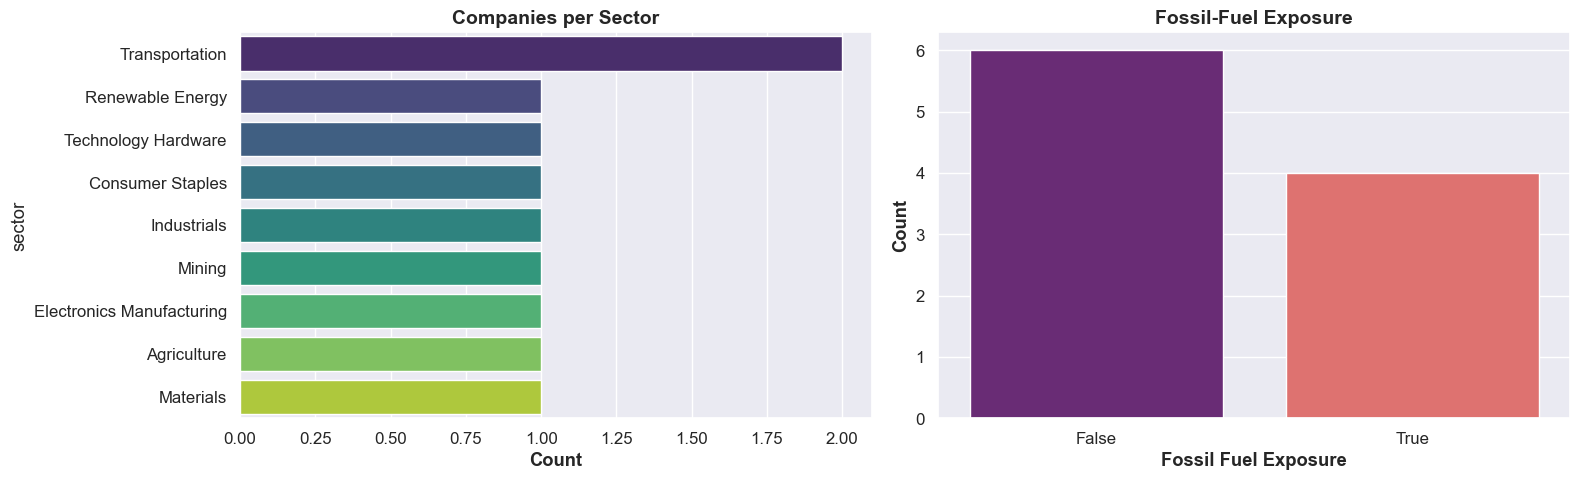

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(data=companies_df, y="sector", ax=axes[0],
              order=companies_df["sector"].value_counts().index, palette="viridis")
axes[0].set_title("Companies per Sector", fontweight="bold", fontsize=14)
axes[0].set_xlabel("Count", fontweight="bold")

sns.countplot(data=companies_df, x="fossil_fuel_exposure", ax=axes[1], palette="magma")
axes[1].set_title("Fossil-Fuel Exposure", fontweight="bold", fontsize=14)
axes[1].set_xlabel("Fossil Fuel Exposure", fontweight="bold")
axes[1].set_ylabel("Count", fontweight="bold")

plt.tight_layout()
plt.show()

<h2 id="Controversy-Analysis" tabindex="0">Controversy Analysis</h2>

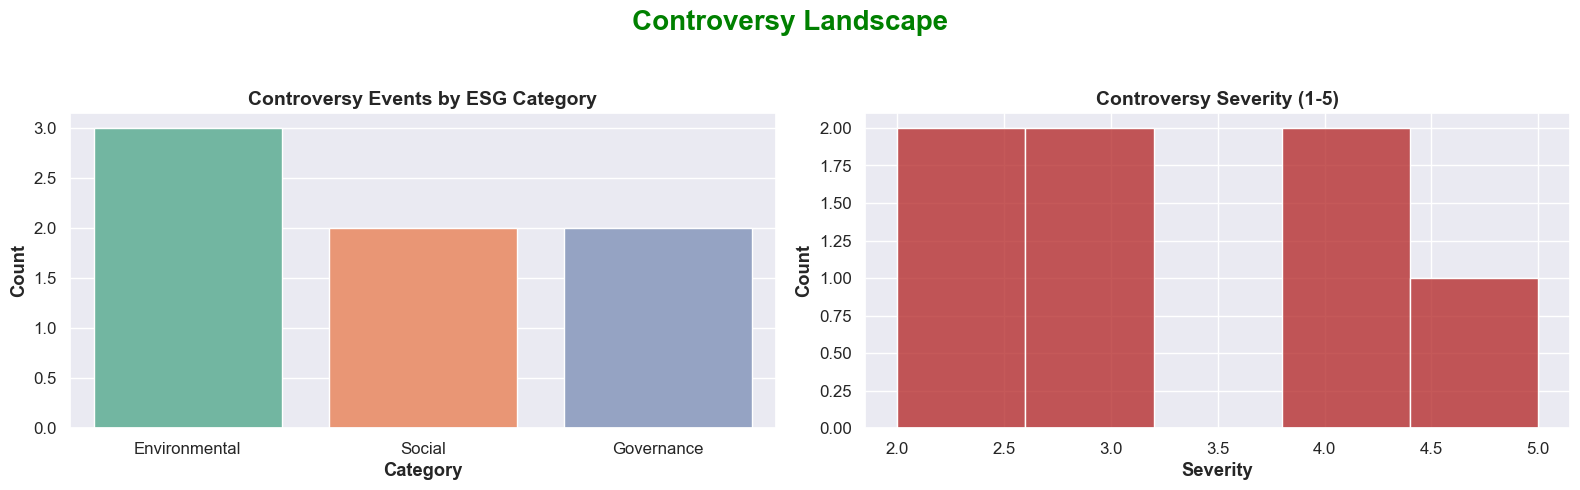

In [11]:
controversies_df = pd.DataFrame(controversies)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(data=controversies_df, x="category", ax=axes[0],
              order=controversies_df["category"].value_counts().index, palette="Set2")
axes[0].set_title("Controversy Events by ESG Category", fontweight="bold", fontsize=14)
axes[0].set_xlabel("Category", fontweight="bold")
axes[0].set_ylabel("Count", fontweight="bold")

sns.histplot(data=controversies_df, x="severity", bins=5, ax=axes[1], color="firebrick")
axes[1].set_title("Controversy Severity (1-5)", fontweight="bold", fontsize=14)
axes[1].set_xlabel("Severity", fontweight="bold")
axes[1].set_ylabel("Count", fontweight="bold")

plt.suptitle("Controversy Landscape", fontsize=20, fontweight="bold", color="green")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

<h2 id="Correlation-Analysis" tabindex="0">Correlation Analysis</h2>

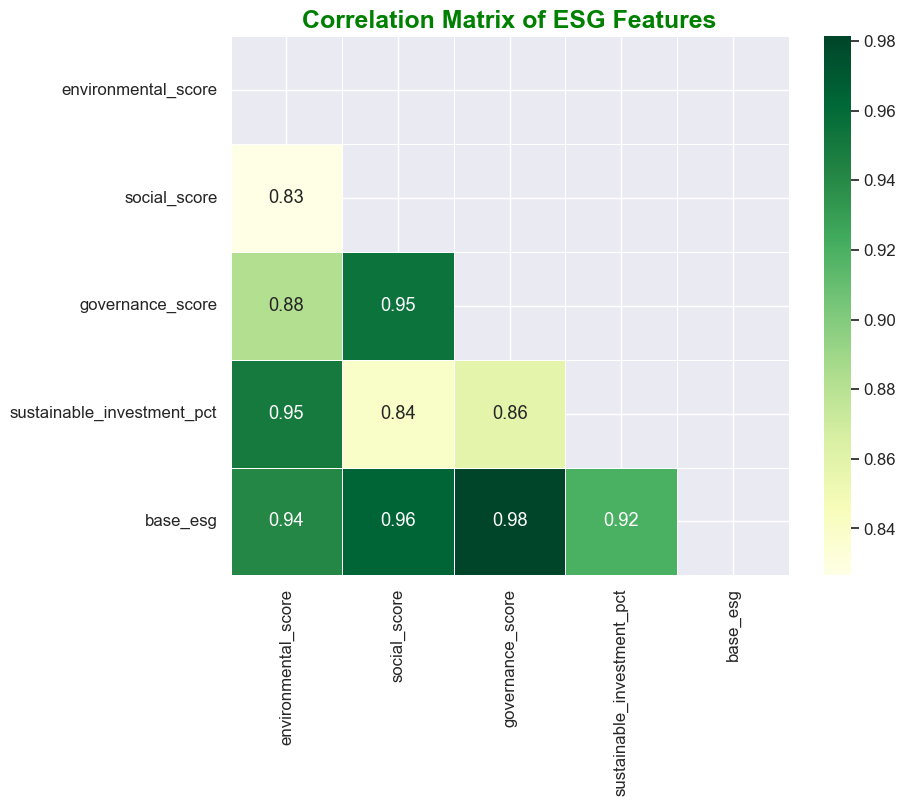

In [12]:
corr = companies_df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="YlGn", linewidths=0.5)
plt.title("Correlation Matrix of ESG Features", fontsize=18, fontweight="bold", color="green")
plt.show()

<h2 id="ESG-by-Sector" tabindex="0">ESG Performance by Sector</h2>

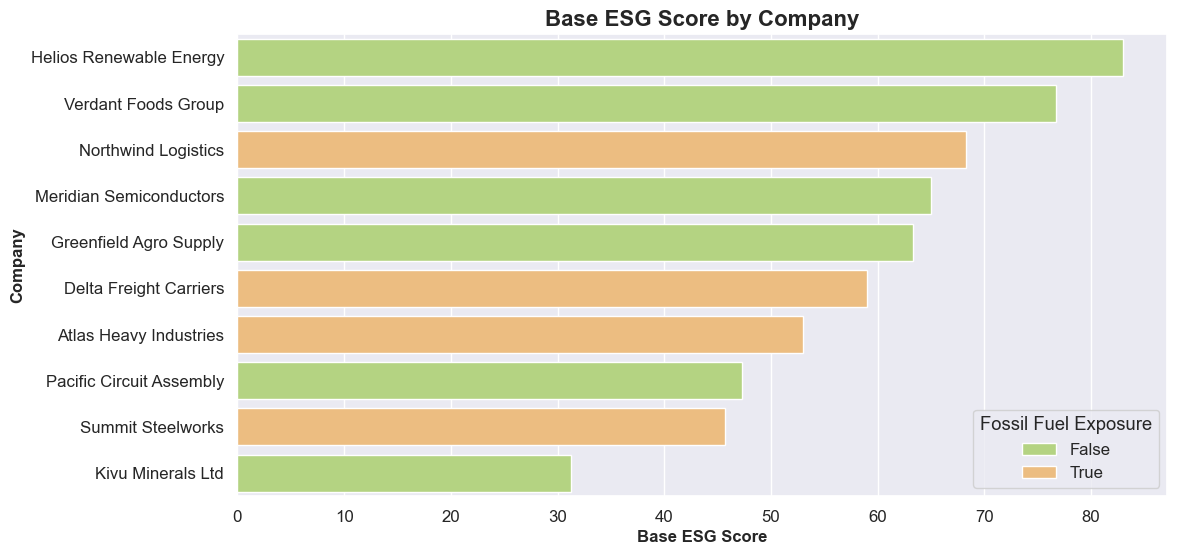

In [13]:
plt.figure(figsize=(12, 6))
sns.barplot(data=companies_df.sort_values("base_esg", ascending=False),
            x="base_esg", y="name", hue="fossil_fuel_exposure", dodge=False, palette="RdYlGn_r")
plt.title("Base ESG Score by Company", fontsize=16, fontweight="bold")
plt.xlabel("Base ESG Score", fontsize=12, fontweight="bold")
plt.ylabel("Company", fontsize=12, fontweight="bold")
plt.legend(title="Fossil Fuel Exposure")
plt.show()

<h1 id="Knowledge-Graph" tabindex="0">🕸️ Knowledge Graph Construction</h1>
<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    The heart of the platform is a <b>Knowledge Graph</b> connecting companies, their suppliers
    and the ESG controversy events attached to each. In production this is a Neo4j graph; here we
    build the identical structure in-memory with <code>networkx</code> as a directed multigraph.
    The graph exposes the neighbourhood queries that GraphRAG and risk propagation need.
</div>

<h2 id="Graph-Schema" tabindex="0">🔗 Graph Schema</h2>
<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    <ul>
        <li><b>Company</b> &rarr; <code>has_controversy</code> &rarr; <b>ESGEvent</b></li>
        <li><b>Company (buyer)</b> &rarr; <code>sources_from</code> &rarr; <b>Company (supplier)</b> (with a tier)</li>
    </ul>
</div>

In [14]:
def build_graph():
    """Construct the ESG knowledge graph from the raw collections."""
    g = nx.MultiDiGraph()

    # Company / supplier nodes (with derived base ESG)
    for c in companies:
        g.add_node(
            c["id"], kind="company",
            **{k: v for k, v in c.items() if k != "id"},
            base_esg=round((c["environmental_score"] + c["social_score"] +
                            c["governance_score"]) / 3, 1),
        )

    # Controversy event nodes + edges
    for ev in controversies:
        g.add_node(ev["id"], kind="controversy", **{k: v for k, v in ev.items() if k != "id"})
        g.add_edge(ev["company_id"], ev["id"], relation="has_controversy")

    # Supply-chain edges (buyer -> supplier)
    for edge in supply_chain:
        g.add_edge(edge["buyer"], edge["supplier"], relation="sources_from",
                   tier=edge["tier"], commodity=edge["commodity"])
    return g


graph = build_graph()
node_kinds = Counter(d["kind"] for _, d in graph.nodes(data=True))
print(f"Knowledge graph built: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges")
print(f"Node kinds: {dict(node_kinds)}")

Knowledge graph built: 17 nodes, 16 edges
Node kinds: {'company': 10, 'controversy': 7}


<h2 id="Graph-Visualization" tabindex="0">Graph Visualization</h2>

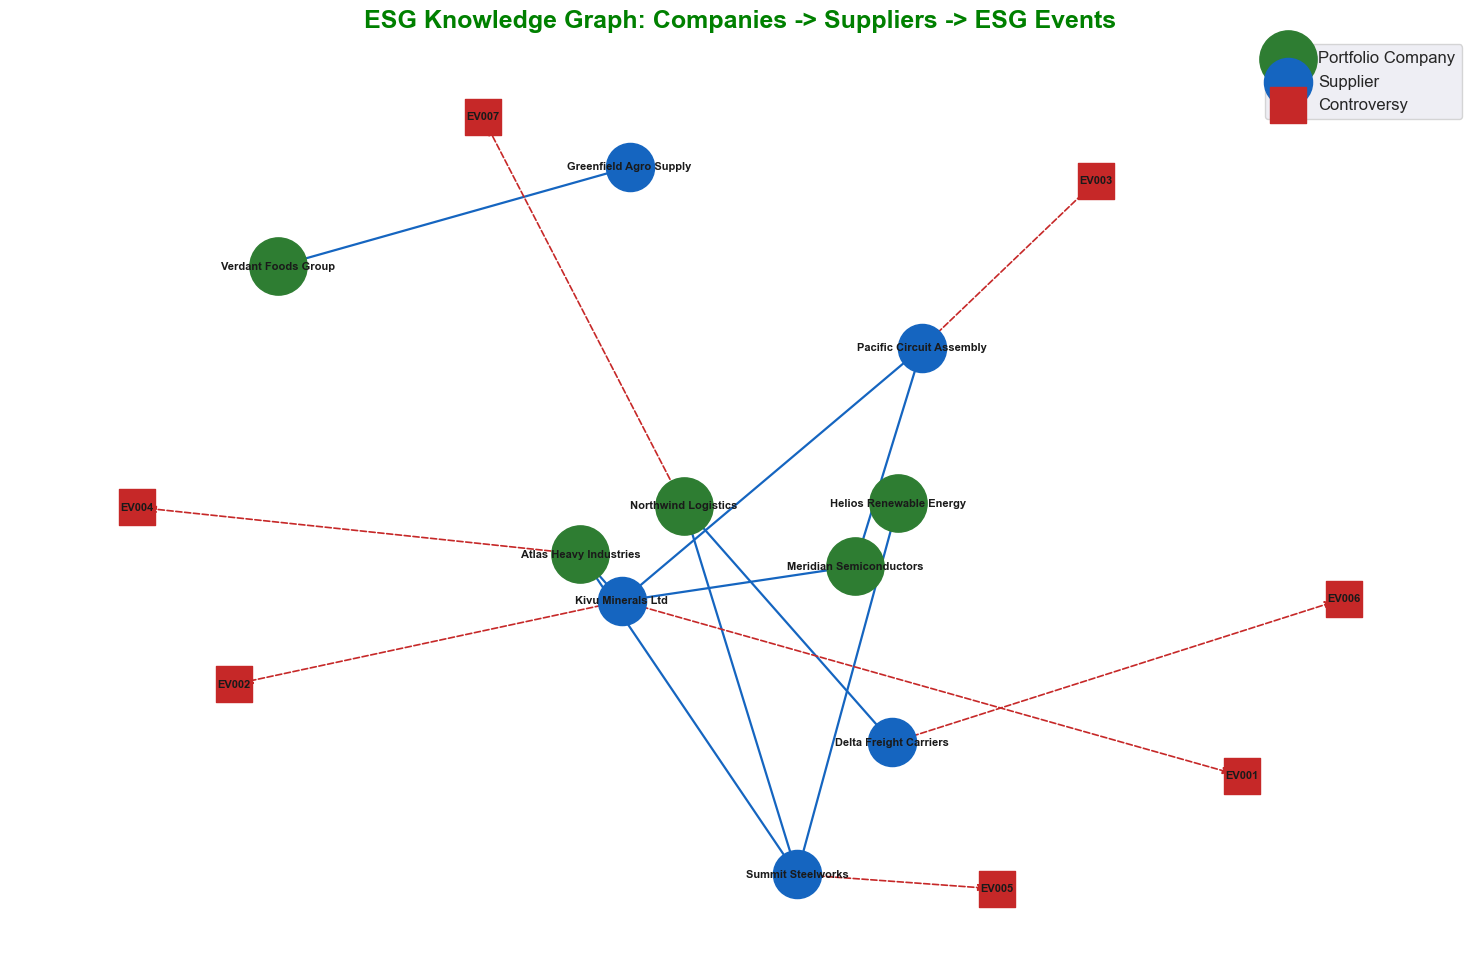

In [15]:
plt.figure(figsize=(15, 10))

company_nodes = [n for n, d in graph.nodes(data=True) if d["kind"] == "company" and d.get("in_portfolio")]
supplier_nodes = [n for n, d in graph.nodes(data=True) if d["kind"] == "company" and not d.get("in_portfolio")]
event_nodes = [n for n, d in graph.nodes(data=True) if d["kind"] == "controversy"]

pos = nx.spring_layout(graph, seed=42, k=0.9)

nx.draw_networkx_nodes(graph, pos, nodelist=company_nodes, node_color="#2e7d32",
                       node_size=1700, label="Portfolio Company")
nx.draw_networkx_nodes(graph, pos, nodelist=supplier_nodes, node_color="#1565c0",
                       node_size=1200, label="Supplier")
nx.draw_networkx_nodes(graph, pos, nodelist=event_nodes, node_color="#c62828",
                       node_size=700, node_shape="s", label="Controversy")

supply_edges = [(u, v) for u, v, d in graph.edges(data=True) if d.get("relation") == "sources_from"]
contro_edges = [(u, v) for u, v, d in graph.edges(data=True) if d.get("relation") == "has_controversy"]
nx.draw_networkx_edges(graph, pos, edgelist=supply_edges, edge_color="#1565c0", arrows=True, width=1.6)
nx.draw_networkx_edges(graph, pos, edgelist=contro_edges, edge_color="#c62828",
                       style="dashed", arrows=True, width=1.2)

labels = {n: (graph.nodes[n].get("name", n) if graph.nodes[n]["kind"] == "company" else n)
          for n in graph.nodes()}
nx.draw_networkx_labels(graph, pos, labels=labels, font_size=8, font_weight="bold")

plt.title("ESG Knowledge Graph: Companies -> Suppliers -> ESG Events",
          fontsize=18, fontweight="bold", color="green")
plt.legend(scatterpoints=1, fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.show()

<h1 id="Risk-Propagation" tabindex="0">⚙️ Supply-Chain Risk Propagation</h1>
<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    A company can look clean on its own filings yet carry severe risk three tiers upstream. We
    propagate every supplier's controversy risk up to its buyers using a transparent
    <b>tier decay</b> (Tier&nbsp;1 = 60%, Tier&nbsp;2 = 30%, Tier&nbsp;3 = 15%). This is the
    proxy for the production graph-ML GNN, and it surfaces the <b>hidden portfolio exposure</b>
    that conventional ratings miss.
</div>

In [16]:
TIER_DECAY = {1: 0.60, 2: 0.30, 3: 0.15}
DEFAULT_DECAY = 0.10


def direct_controversy_risk(g, node):
    """Sum of severities of controversies attached directly to a node (0-100 scale)."""
    risk = 0.0
    for _, target, attrs in g.out_edges(node, data=True):
        if attrs.get("relation") == "has_controversy":
            risk += g.nodes[target]["severity"] * 4   # severity 1-5 -> 0-20 each
    return min(risk, 100.0)


def propagate_supply_chain_risk(g):
    """Propagate controversy risk from suppliers up to buyers (GNN proxy)."""
    result = {}
    for node, attrs in g.nodes(data=True):
        if attrs.get("kind") != "company":
            continue
        direct = direct_controversy_risk(g, node)
        inherited, contributors = 0.0, []
        for supplier in nx.descendants(g, node):
            if g.nodes[supplier].get("kind") != "company":
                continue
            try:
                hops = nx.shortest_path_length(g, node, supplier)
            except nx.NetworkXNoPath:
                continue
            decay = TIER_DECAY.get(hops, DEFAULT_DECAY)
            supplier_risk = direct_controversy_risk(g, supplier)
            flowed = supplier_risk * decay
            if flowed > 0:
                inherited += flowed
                contributors.append({
                    "supplier_id": supplier, "supplier_name": g.nodes[supplier]["name"],
                    "tier": hops, "supplier_risk": round(supplier_risk, 1),
                    "propagated_risk": round(flowed, 1),
                })
        inherited = min(inherited, 100.0)
        contributors.sort(key=lambda x: x["propagated_risk"], reverse=True)
        result[node] = {
            "company_id": node, "name": attrs["name"], "base_esg": attrs["base_esg"],
            "direct_controversy_risk": round(direct, 1),
            "supply_chain_risk": round(inherited, 1),
            "composite_esg": round(max(0.0, attrs["base_esg"] - 0.5 * direct - 0.4 * inherited), 1),
            "supplier_contributors": contributors,
        }
    return result


risk = propagate_supply_chain_risk(graph)
risk_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != "supplier_contributors"}
    for r in risk.values() if graph.nodes[r["company_id"]].get("in_portfolio")
]).sort_values("composite_esg", ascending=False).reset_index(drop=True)
risk_df

,company_id,name,base_esg,direct_controversy_risk,supply_chain_risk,composite_esg
0,C001,Helios Renewable Energy,83.0,0.0,7.2,80.1
1,C004,Verdant Foods Group,76.7,0.0,0.0,76.7
2,C002,Northwind Logistics,68.3,8.0,12.0,59.5
3,C003,Meridian Semiconductors,65.0,0.0,28.8,53.5
4,C005,Atlas Heavy Industries,53.0,16.0,28.8,33.5


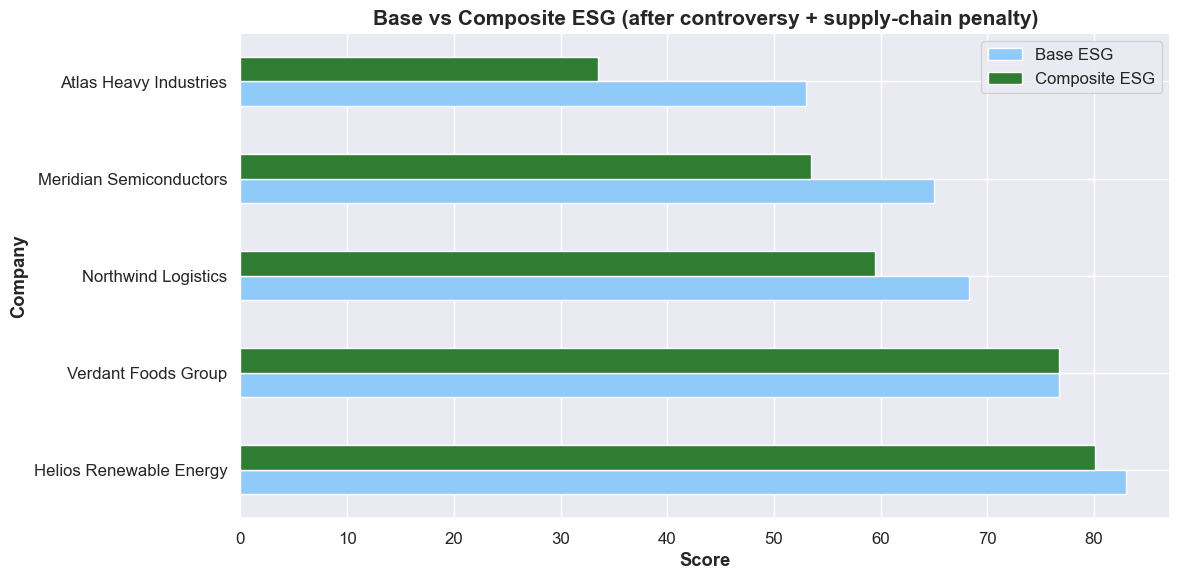

In [17]:
plt.figure(figsize=(12, 6))
plot_df = risk_df.set_index("name")[["base_esg", "composite_esg"]]
plot_df.plot(kind="barh", ax=plt.gca(), color=["#90caf9", "#2e7d32"])
plt.title("Base vs Composite ESG (after controversy + supply-chain penalty)",
          fontsize=15, fontweight="bold")
plt.xlabel("Score", fontweight="bold")
plt.ylabel("Company", fontweight="bold")
plt.legend(["Base ESG", "Composite ESG"])
plt.tight_layout()
plt.show()

<h1 id="NLP-Classifier" tabindex="0">🧠 NLP ESG Classifier</h1>
<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    Each sentence in a filing is labelled <b>Environmental / Social / Governance</b> with a
    pseudo-confidence. The full platform uses HuggingFace <b>FinBERT</b>; here a transparent,
    keyword-weighted classifier reproduces the same interface so it can be swapped one-for-one.
</div>

In [18]:
LEXICON = {
    "Environmental": ["emission", "emissions", "nox", "carbon", "climate", "scope", "pollution",
                       "water", "deforestation", "fossil", "renewable", "solar", "wind",
                       "tailings", "waste", "net-zero", "taxonomy"],
    "Social": ["labor", "labour", "overtime", "rights", "conflict", "mineral", "minerals",
               "community", "human", "safety", "health", "worker", "artisanal", "diversity"],
    "Governance": ["board", "governance", "antitrust", "anti-competition", "disclosure", "audit",
                   "due-diligence", "compliance", "oversight", "committee", "bribery", "csrd",
                   "regulator", "reform"],
}
_WORD_RE = re.compile(r"[a-zA-Z\-]+")


def classify_sentence(sentence):
    tokens = [t.lower() for t in _WORD_RE.findall(sentence)]
    scores = Counter({p: sum(tokens.count(w) for w in words) for p, words in LEXICON.items()})
    total = sum(scores.values())
    if total == 0:
        return {"label": "Neutral", "confidence": 0.0, "scores": dict(scores)}
    label, hits = scores.most_common(1)[0]
    return {"label": label, "confidence": round(hits / total, 3), "scores": dict(scores)}


def classify_document(text):
    sentences = [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if s.strip()]
    out = []
    for sent in sentences:
        r = classify_sentence(sent)
        r["sentence"] = sent
        out.append(r)
    return out


# Classify every sentence across all filings
rows = []
for doc in documents:
    for r in classify_document(doc["text"]):
        rows.append({"company_id": doc["company_id"], "label": r["label"],
                     "confidence": r["confidence"], "sentence": r["sentence"]})
sentences_df = pd.DataFrame(rows)
print(f"Classified {len(sentences_df)} sentences across {len(documents)} filings")
sentences_df.head(8)

Classified 13 sentences across 5 filings


,company_id,label,confidence,sentence
0,C001,Environmental,1.00,Helios Renewable Energy generates 91 percent o...
1,C001,Environmental,1.00,The company reports net-zero scope 1 and 2 emi...
2,C001,Governance,0.75,Board oversight of climate risk is formalised ...
3,C002,Environmental,1.00,Northwind Logistics operates a diesel-heavy ro...
4,C002,Environmental,1.00,The company has committed to fleet electrifica...
5,C002,Governance,1.00,A mandatory CSRD disclosure was filed late thi...
6,C003,Social,1.00,Meridian Semiconductors assembles circuit boar...
7,C003,Governance,1.00,The company acknowledges conflict-mineral due-...


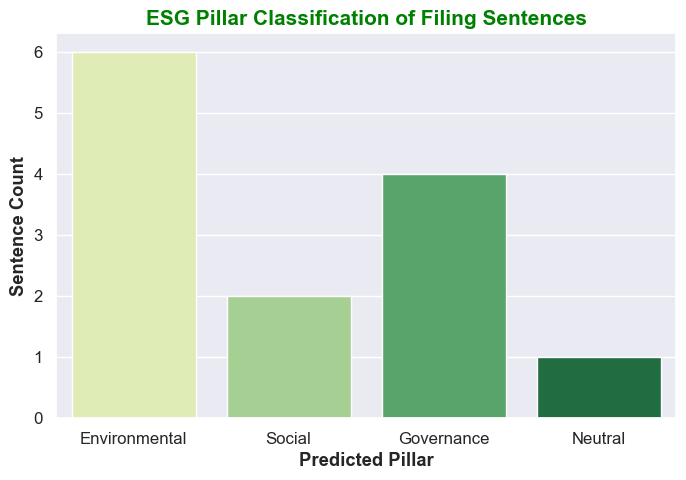

In [19]:
plt.figure(figsize=(8, 5))
order = ["Environmental", "Social", "Governance", "Neutral"]
sns.countplot(data=sentences_df, x="label", order=order, palette="YlGn")
plt.title("ESG Pillar Classification of Filing Sentences", fontsize=15, fontweight="bold", color="green")
plt.xlabel("Predicted Pillar", fontweight="bold")
plt.ylabel("Sentence Count", fontweight="bold")
plt.show()

<h1 id="GraphRAG" tabindex="0">🔎 GraphRAG Retrieval</h1>
<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    <b>GraphRAG</b> combines two signals that together give multi-hop behaviour plain vector RAG
    cannot: (1) <b>document relevance</b> via TF-IDF cosine similarity, and (2) <b>graph
    expansion</b> &mdash; every company surfaced is expanded along its supply-chain edges so
    upstream suppliers and their controversies join the evidence chain.
</div>

In [20]:
class GraphRAGRetriever:
    def __init__(self, graph, documents):
        self.graph = graph
        self.documents = documents
        self._corpus = [d["text"] for d in documents]
        self._vectorizer = TfidfVectorizer(stop_words="english")
        self._doc_matrix = self._vectorizer.fit_transform(self._corpus)

    def _rank_documents(self, query, top_k):
        q_vec = self._vectorizer.transform([query])
        sims = cosine_similarity(q_vec, self._doc_matrix).ravel()
        ranked = sorted(zip(self.documents, sims), key=lambda x: x[1], reverse=True)
        return [{**doc, "relevance": round(float(score), 3)}
                for doc, score in ranked[:top_k] if score > 0]

    def _expand_evidence(self, company_id):
        g = self.graph
        evidence = {"company_id": company_id, "name": g.nodes[company_id]["name"],
                    "controversies": [], "supply_chain": []}
        for _, tgt, attrs in g.out_edges(company_id, data=True):
            if attrs.get("relation") == "has_controversy":
                evidence["controversies"].append(g.nodes[tgt]["headline"])
        for supplier in nx.descendants(g, company_id):
            if g.nodes[supplier].get("kind") != "company":
                continue
            sup_controversies = [g.nodes[t]["headline"]
                                 for _, t, a in g.out_edges(supplier, data=True)
                                 if a.get("relation") == "has_controversy"]
            evidence["supply_chain"].append({
                "supplier_id": supplier, "supplier_name": g.nodes[supplier]["name"],
                "tier": nx.shortest_path_length(g, company_id, supplier),
                "controversies": sup_controversies,
            })
        return evidence

    def retrieve(self, query, top_k=3):
        docs = self._rank_documents(query, top_k)
        evidence = [self._expand_evidence(d["company_id"]) for d in docs]
        return {"query": query, "documents": docs, "evidence": evidence}


retriever = GraphRAGRetriever(graph, documents)
question = "Which portfolio companies have conflict-mineral supply-chain exposure?"
retrieved = retriever.retrieve(question, top_k=3)

print(f"Q: {question}\n")
pd.DataFrame([{"company_id": d["company_id"], "source": d["source"],
               "relevance": d["relevance"]} for d in retrieved["documents"]])

Q: Which portfolio companies have conflict-mineral supply-chain exposure?



,company_id,source,relevance
0,C003,SEC EDGAR 10-K / Supplier Disclosure,0.186
1,C004,SEC EDGAR 10-K / Sustainability Report,0.102
2,C005,SEC EDGAR 10-K / Regulator Filing,0.064


<h1 id="Narrative" tabindex="0">📝 Narrative Generation</h1>
<div class="alert alert-block alert-info" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    The retrieved evidence chain is turned into a short, grounded, <b>evidence-cited</b> ESG
    narrative. A deterministic template stands in for the Llama&nbsp;3.1 generator and consumes
    the same evidence structure, so a real LLM call is a drop-in replacement later.
</div>

In [21]:
def generate_narrative(evidence, company_risk=None):
    name = evidence["name"]
    parts = []
    if company_risk:
        parts.append(
            f"{name} carries a composite ESG score of {company_risk['composite_esg']}/100 "
            f"(base {company_risk['base_esg']}), with a direct controversy risk of "
            f"{company_risk['direct_controversy_risk']} and inherited supply-chain risk of "
            f"{company_risk['supply_chain_risk']}.")
    else:
        parts.append(f"ESG evidence summary for {name}.")

    if evidence["controversies"]:
        parts.append("Direct controversies on record: " + "; ".join(evidence["controversies"]) + ".")
    else:
        parts.append("No direct controversies are on record for this entity.")

    flagged = [s for s in evidence["supply_chain"] if s["controversies"]]
    if flagged:
        chains = [f"{s['supplier_name']} (Tier {s['tier']}: " + "; ".join(s["controversies"]) + ")"
                  for s in flagged]
        parts.append("Upstream supply-chain exposure traces to " + " | ".join(chains) + ".")
    else:
        parts.append("No controversy exposure was found in the upstream supply chain.")

    parts.append("This assessment is grounded in retrieved filing evidence and is traceable to "
                 "the cited source documents.")
    return " ".join(parts)


for ev in retrieved["evidence"]:
    narrative = generate_narrative(ev, risk.get(ev["company_id"]))
    print(f"• {ev['name']}")
    print(f"  {narrative}\n")

• Meridian Semiconductors
  Meridian Semiconductors carries a composite ESG score of 53.5/100 (base 65.0), with a direct controversy risk of 0.0 and inherited supply-chain risk of 28.8. No direct controversies are on record for this entity. Upstream supply-chain exposure traces to Pacific Circuit Assembly (Tier 1: Pacific Circuit Assembly cited for excessive overtime at two plants) | Kivu Minerals Ltd (Tier 1: Kivu Minerals linked to conflict-mineral sourcing in artisanal mines; Tailings discharge contaminates local watershed near Kivu operations). This assessment is grounded in retrieved filing evidence and is traceable to the cited source documents.

• Verdant Foods Group
  Verdant Foods Group carries a composite ESG score of 76.7/100 (base 76.7), with a direct controversy risk of 0.0 and inherited supply-chain risk of 0.0. No direct controversies are on record for this entity. No controversy exposure was found in the upstream supply chain. This assessment is grounded in retrieved fi

<h1 id="SFDR" tabindex="0">🏛️ SFDR Compliance Classification</h1>
<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    Finally, each company is mapped to its EU <b>SFDR</b> category with a clause-level
    justification for every decision: <b>Article&nbsp;9</b> (sustainable investment objective),
    <b>Article&nbsp;8</b> (promotes E/S characteristics) or <b>Article&nbsp;6</b> (no
    sustainability claim). The composite ESG score &mdash; after risk propagation &mdash; drives
    the classification.
</div>

In [22]:
ART9_MIN_SUSTAINABLE, ART9_MIN_ESG = 0.80, 75
ART8_MIN_SUSTAINABLE, ART8_MIN_ESG = 0.30, 60


def classify_sfdr(company, composite_esg=None):
    base_esg = (company["environmental_score"] + company["social_score"] +
                company["governance_score"]) / 3
    esg = composite_esg if composite_esg is not None else base_esg
    sustainable, fossil = company["sustainable_investment_pct"], company["fossil_fuel_exposure"]
    reasons = []

    if sustainable >= ART9_MIN_SUSTAINABLE and esg >= ART9_MIN_ESG and not fossil:
        reasons = [f"Sustainable investment {sustainable:.0%} >= {ART9_MIN_SUSTAINABLE:.0%} (objective).",
                   f"Composite ESG {esg:.1f} >= {ART9_MIN_ESG} threshold.",
                   "No fossil-fuel exposure - consistent with EU Taxonomy alignment."]
        return _result("Article 9", "Sustainable investment objective", reasons, esg)

    if sustainable >= ART8_MIN_SUSTAINABLE and esg >= ART8_MIN_ESG:
        reasons = [f"Sustainable investment {sustainable:.0%} >= {ART8_MIN_SUSTAINABLE:.0%} (promotes E/S).",
                   f"Composite ESG {esg:.1f} >= {ART8_MIN_ESG} threshold."]
        reasons.append("Note: residual fossil-fuel exposure caps below Article 9." if fossil
                       else "No fossil-fuel exposure.")
        return _result("Article 8", "Promotes E/S characteristics", reasons, esg)

    if sustainable < ART8_MIN_SUSTAINABLE:
        reasons.append(f"Sustainable investment {sustainable:.0%} < {ART8_MIN_SUSTAINABLE:.0%} minimum.")
    if esg < ART8_MIN_ESG:
        reasons.append(f"Composite ESG {esg:.1f} < {ART8_MIN_ESG} threshold.")
    if fossil:
        reasons.append("Fossil-fuel exposure present.")
    return _result("Article 6", "No sustainability claim", reasons, esg)


def _result(article, label, reasons, esg):
    return {"sfdr_article": article, "classification": label,
            "composite_esg_used": round(esg, 1), "justifications": reasons}


# Build the full portfolio scoreboard
scoreboard = []
for c in companies:
    if not c["in_portfolio"]:
        continue
    r = risk[c["id"]]
    s = classify_sfdr(c, r["composite_esg"])
    scoreboard.append({
        "name": c["name"], "sector": c["sector"],
        "base_esg": r["base_esg"], "composite_esg": r["composite_esg"],
        "supply_chain_risk": r["supply_chain_risk"], "sfdr_article": s["sfdr_article"],
    })

scoreboard_df = pd.DataFrame(scoreboard).sort_values("composite_esg", ascending=False).reset_index(drop=True)
scoreboard_df

,name,sector,base_esg,composite_esg,supply_chain_risk,sfdr_article
0,Helios Renewable Energy,Renewable Energy,83.0,80.1,7.2,Article 9
1,Verdant Foods Group,Consumer Staples,76.7,76.7,0.0,Article 8
2,Northwind Logistics,Transportation,68.3,59.5,12.0,Article 6
3,Meridian Semiconductors,Technology Hardware,65.0,53.5,28.8,Article 6
4,Atlas Heavy Industries,Industrials,53.0,33.5,28.8,Article 6


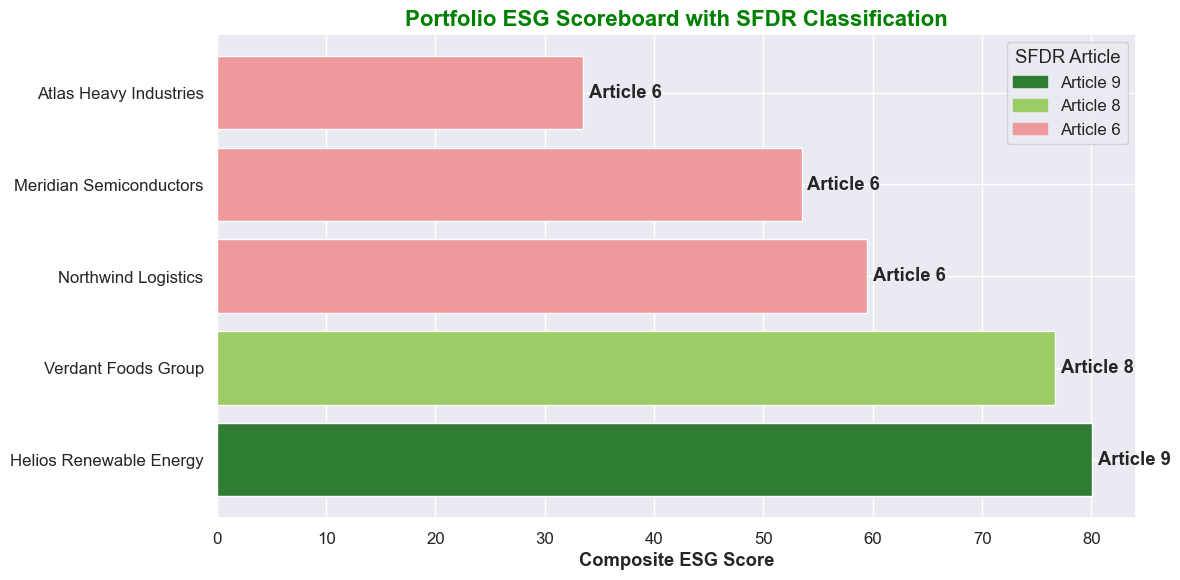

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))
palette = {"Article 9": "#2e7d32", "Article 8": "#9ccc65", "Article 6": "#ef9a9a"}
colors = scoreboard_df["sfdr_article"].map(palette)
ax.barh(scoreboard_df["name"], scoreboard_df["composite_esg"], color=colors)
ax.set_xlabel("Composite ESG Score", fontweight="bold")
ax.set_title("Portfolio ESG Scoreboard with SFDR Classification",
             fontsize=16, fontweight="bold", color="green")
for i, (_, row) in enumerate(scoreboard_df.iterrows()):
    ax.text(row["composite_esg"] + 0.5, i, row["sfdr_article"], va="center", fontweight="bold")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in palette.values()]
ax.legend(handles, palette.keys(), title="SFDR Article")
plt.tight_layout()
plt.show()

<h1 id="Conclusion" tabindex="0">🎯 Conclusion</h1>
<div class="alert alert-block alert-success" style="font-family: verdana; font-size: 20px; line-height: 1.7em; border-radius: 1.3em;">
    From this project we built, end-to-end, a free alternative to institutional ESG ratings:
    <ul>
        <li><b>Ingested</b> multi-source ESG data (company scores, supply chain, controversies, filings) into a single model.</li>
        <li>Built a <b>Knowledge Graph</b> of companies, suppliers and ESG events with <code>networkx</code>.</li>
        <li><b>Propagated supply-chain risk</b> across tiers so hidden upstream exposure surfaces on portfolio buyers.</li>
        <li>Implemented <b>GraphRAG</b> &mdash; multi-hop retrieval that vector RAG alone cannot perform.</li>
        <li>Generated grounded, <b>evidence-cited ESG narratives</b> from the retrieved graph evidence.</li>
        <li>Automated <b>SFDR Article 8 / 9 / 6</b> classification with auditable, per-rule justifications.</li>
    </ul>
    The whole pipeline runs with no GPU, no database and no API keys &mdash; an instantly
    reproducible, transparent ESG intelligence platform.
</div>

<div style="font-family: verdana; font-size: 22px; text-align: center; color: #2e7d32;">
    <b><i>Thank you for reading, happy learning!</i></b>
</div>

<center>
    <img src="https://media.giphy.com/media/Gz6nYcm8oXE4dFTC8j/giphy.gif" height="200" width="300">
</center>